<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dropout and Augmentation (4pt)

Test the dropout so that it is first only in the fully connected layer (p = 0.5) and then also after the convolutional layers (p = 0.2). And one more option. Remember to use Dropout2d instead of Dropout1d when using in convolution layers.

Test augmentation for 3 different settings. You can be creative, but it should at least make sense. Documentation can be found [here](https://pytorch.org/vision/stable/transforms.html). Be careful to do it right.

Test both things for two cases in one you use a regular split on train/val and in the other you leave only the first 1000 examples in the training set. Be aware that the number of training steps is smaller for the second case, so use proportionately more epochs.

In [1]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-10 10:52:23--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.02s   

2025-11-10 10:52:23 (15.6 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-10 10:52:23--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443.

In [2]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:04<00:00, 36.7MB/s]


torch.Size([1, 3, 32, 32])


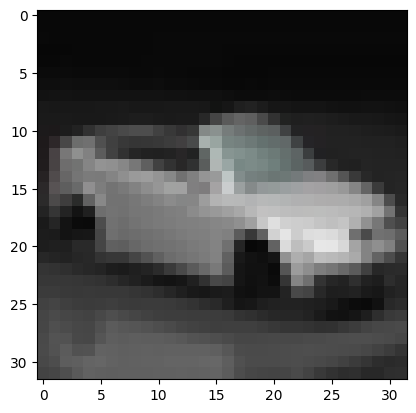

tensor([1])
car
torch.Size([1, 3, 32, 32])


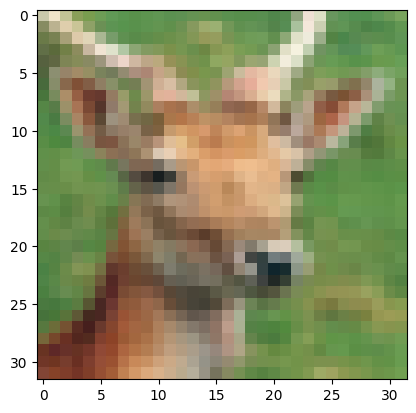

tensor([4])
deer
torch.Size([1, 3, 32, 32])


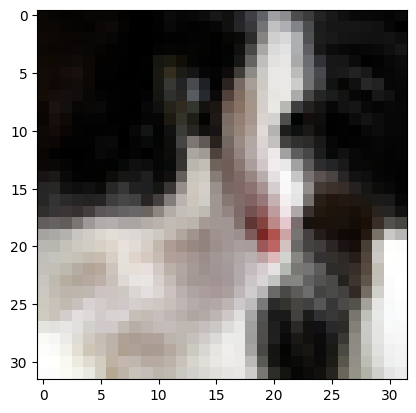

tensor([3])
cat
torch.Size([1, 3, 32, 32])


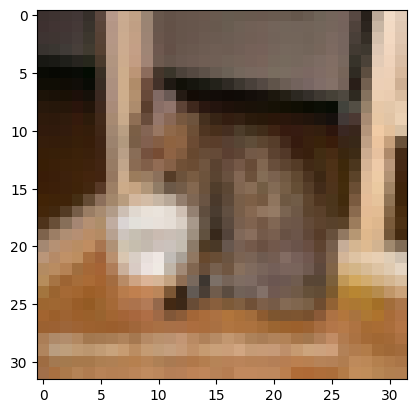

tensor([3])
cat
torch.Size([1, 3, 32, 32])


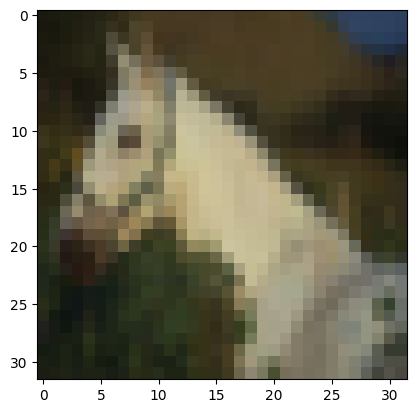

tensor([7])
horse
torch.Size([1, 3, 32, 32])


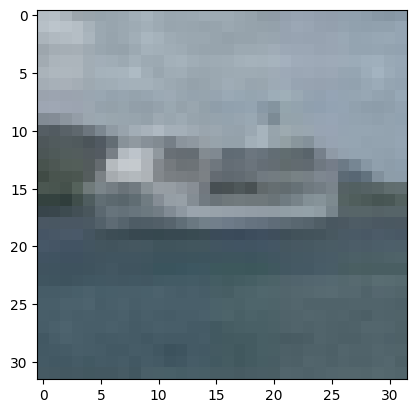

tensor([8])
ship
torch.Size([1, 3, 32, 32])


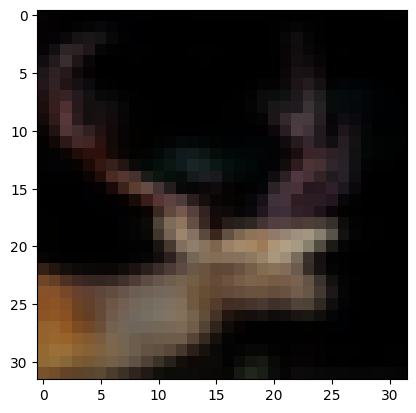

tensor([4])
deer
torch.Size([1, 3, 32, 32])


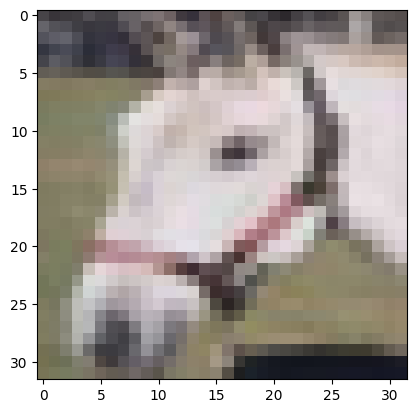

tensor([7])
horse
torch.Size([1, 3, 32, 32])


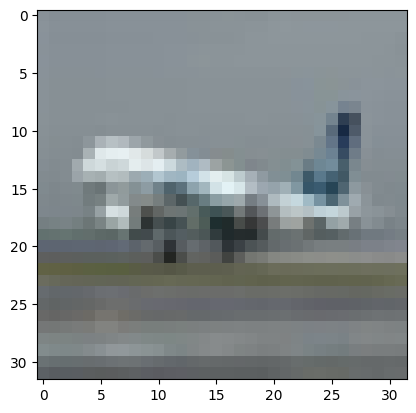

tensor([0])
plane
torch.Size([1, 3, 32, 32])


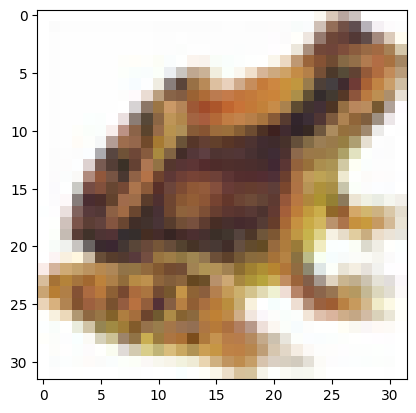

tensor([6])
frog
torch.Size([1, 3, 32, 32])


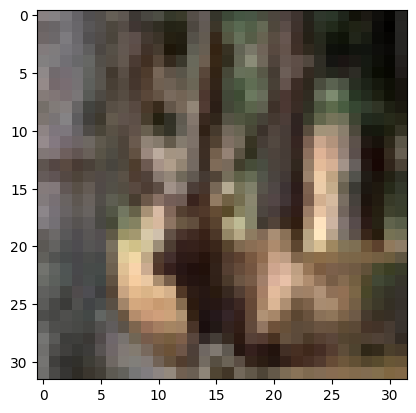

tensor([4])
deer


In [4]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [5]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, Dropout, Dropout2d

def build_model_task4_fc_only(num_classes=10, p_fc=0.5):
    model = Sequential(
          Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),
          Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),
          Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),

          AdaptiveAvgPool2d(1),
          Dropout(p=p_fc),
          Flatten(),
          Linear(128, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_task4_both(num_classes=10, p_conv=0.2, p_fc=0.5):
    model = Sequential(
          Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),
          Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),
          Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),

          AdaptiveAvgPool2d(1),
          Dropout(p=p_fc),
          Flatten(),
          Linear(128, num_classes)
      )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_task4_conv_only(num_classes=10, p_conv=0.2):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, num_classes)
      )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


model, model_inference = build_model_task4_conv_only()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1014, 0.0971, 0.0982, 0.1005, 0.1067, 0.0978, 0.0993, 0.1006, 0.1053,
         0.0932]], grad_fn=<SoftmaxBackward0>)
deer


In [6]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Trying dropout setting: fc_dropout(p=0.5)
Val loss at epoch 0: 1.6371925029025716
Val acc at epoch 0: 0.4106
Val loss at epoch 1: 1.4176406161800312
Val acc at epoch 1: 0.492
Val loss at epoch 2: 1.3478575348854065
Val acc at epoch 2: 0.521
Val loss at epoch 3: 1.246736466884613
Val acc at epoch 3: 0.5618
Val loss at epoch 4: 1.1699493956413998
Val acc at epoch 4: 0.5854
Val loss at epoch 5: 1.1712306058330901
Val acc at epoch 5: 0.5994
Val loss at epoch 6: 1.1087830761435684
Val acc at epoch 6: 0.604
Val loss at epoch 7: 1.0468783078679613
Val acc at epoch 7: 0.6246
Val loss at epoch 8: 0.9948503959710431
Val acc at epoch 8: 0.6536
Val loss at epoch 9: 0.9690952661690438
Val acc at epoch 9: 0.659
Val loss at epoch 10: 0.9617609286763865
Val acc at epoch 10: 0.6644
Val loss at epoch 11: 0.9122321415858664
Val acc at epoch 11: 0.682
Val loss at epoch 12: 0.8766170238992971
Val acc at epoch 12: 0.6912
Val loss at epoch 13: 0.9203124942293592
Val acc at epoch 13: 0.6

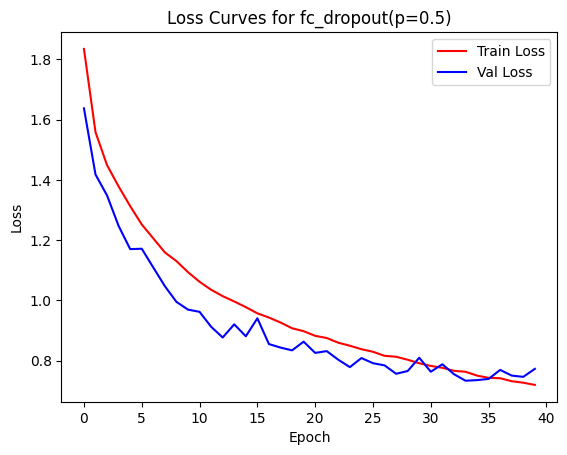

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.2)
Val loss at epoch 0: 1.696765946734483
Val acc at epoch 0: 0.3746
Val loss at epoch 1: 1.5125355978680264
Val acc at epoch 1: 0.4562
Val loss at epoch 2: 1.433918936996703
Val acc at epoch 2: 0.488
Val loss at epoch 3: 1.374603373989178
Val acc at epoch 3: 0.5208
Val loss at epoch 4: 1.3319265515940963
Val acc at epoch 4: 0.55
Val loss at epoch 5: 1.2754352301549001
Val acc at epoch 5: 0.5608
Val loss at epoch 6: 1.2303283840987334
Val acc at epoch 6: 0.572
Val loss at epoch 7: 1.2224359789471717
Val acc at epoch 7: 0.5866
Val loss at epoch 8: 1.1642816476761155
Val acc at epoch 8: 0.5952
Val loss at epoch 9: 1.1492206628914852
Val acc at epoch 9: 0.6026
Val loss at epoch 10: 1.1518966361975214
Val acc at epoch 10: 0.603
Val loss at epoch 11: 1.1024470822826313
Val acc at epoch 11: 0.615
Val loss at epoch 12: 1.099999494613356
Val acc at epoch 12: 0.6234
Val loss at epoch 13: 1.0972622621590924
Val acc at epoch 13: 0.6296


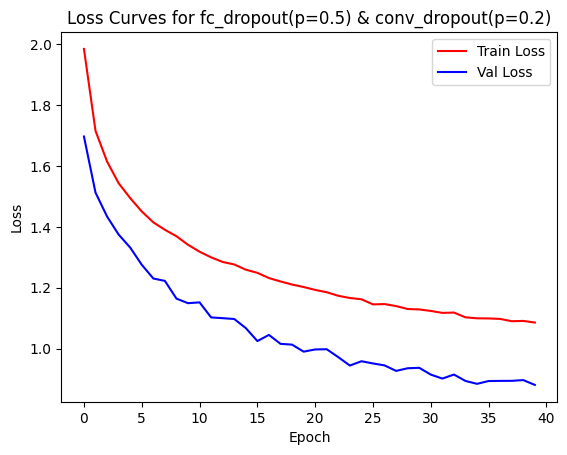

Trying dropout setting: conv_dropout(p=0.2)
Val loss at epoch 0: 1.5913697352075273
Val acc at epoch 0: 0.4388
Val loss at epoch 1: 1.4291946690553312
Val acc at epoch 1: 0.497
Val loss at epoch 2: 1.3389791933594235
Val acc at epoch 2: 0.5342
Val loss at epoch 3: 1.2563413305647055
Val acc at epoch 3: 0.556
Val loss at epoch 4: 1.1792478307037597
Val acc at epoch 4: 0.5796
Val loss at epoch 5: 1.1230086346340786
Val acc at epoch 5: 0.6106
Val loss at epoch 6: 1.0974095915533175
Val acc at epoch 6: 0.6218
Val loss at epoch 7: 1.0628094035349074
Val acc at epoch 7: 0.634
Val loss at epoch 8: 1.0199926146276437
Val acc at epoch 8: 0.6414
Val loss at epoch 9: 0.9781781920961513
Val acc at epoch 9: 0.6638
Val loss at epoch 10: 0.9521394558013625
Val acc at epoch 10: 0.6744
Val loss at epoch 11: 0.9435745359985692
Val acc at epoch 11: 0.6772
Val loss at epoch 12: 0.9014080405994586
Val acc at epoch 12: 0.686
Val loss at epoch 13: 0.8977156721862258
Val acc at epoch 13: 0.687
Val loss at epo

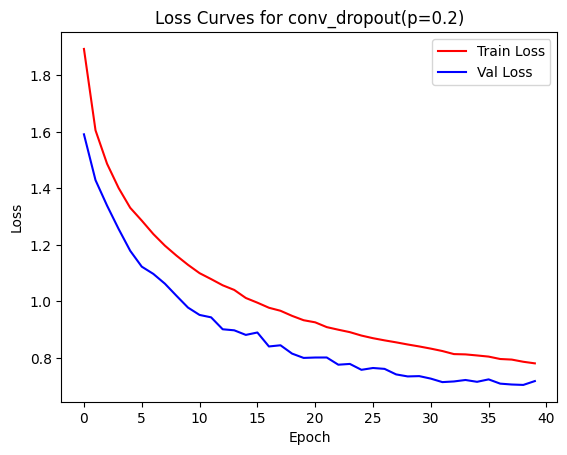

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.1)
Val loss at epoch 0: 1.6664770256941486
Val acc at epoch 0: 0.3978
Val loss at epoch 1: 1.5083755512905728
Val acc at epoch 1: 0.4758
Val loss at epoch 2: 1.3971986337831825
Val acc at epoch 2: 0.4962
Val loss at epoch 3: 1.3274211758261274
Val acc at epoch 3: 0.5308
Val loss at epoch 4: 1.2601568660918314
Val acc at epoch 4: 0.5514
Val loss at epoch 5: 1.2024666181035861
Val acc at epoch 5: 0.582
Val loss at epoch 6: 1.1503429819064535
Val acc at epoch 6: 0.5946
Val loss at epoch 7: 1.1511236482365117
Val acc at epoch 7: 0.6046
Val loss at epoch 8: 1.123895322061648
Val acc at epoch 8: 0.608
Val loss at epoch 9: 1.0991517878641748
Val acc at epoch 9: 0.6206
Val loss at epoch 10: 1.0572079978171427
Val acc at epoch 10: 0.6458
Val loss at epoch 11: 1.0250220310156513
Val acc at epoch 11: 0.6528
Val loss at epoch 12: 1.0009498288676997
Val acc at epoch 12: 0.6576
Val loss at epoch 13: 0.9812612503197542
Val acc at epoch 13: 

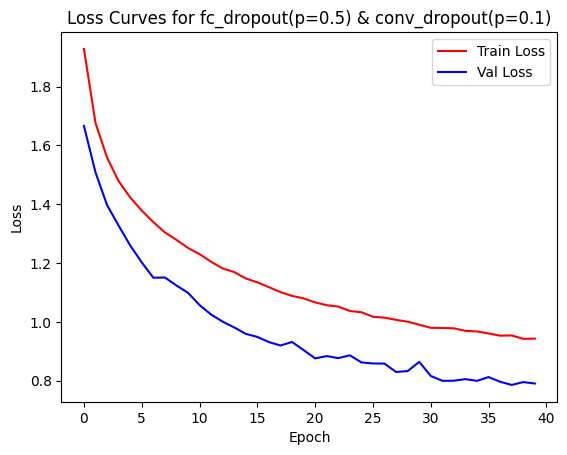

In [7]:
configs = [ {'name': 'fc_dropout(p=0.5)','build_model': lambda: build_model_task4_fc_only(10, 0.5)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.2)},
            {'name': 'conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_conv_only(10, p_conv=0.2)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.1)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.1)}
          ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying dropout setting: {config['name']}")

    model_builder = config['build_model']

    model, model_inference = model_builder()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(40):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [8]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'dropout_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to dropout_results.json


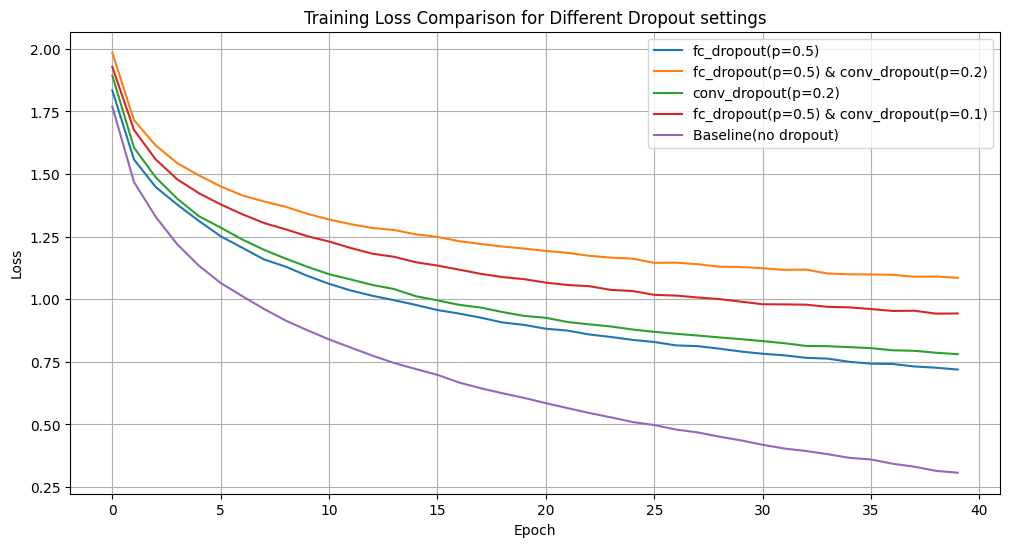

In [9]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline(no dropout)')

plt.title('Training Loss Comparison for Different Dropout settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

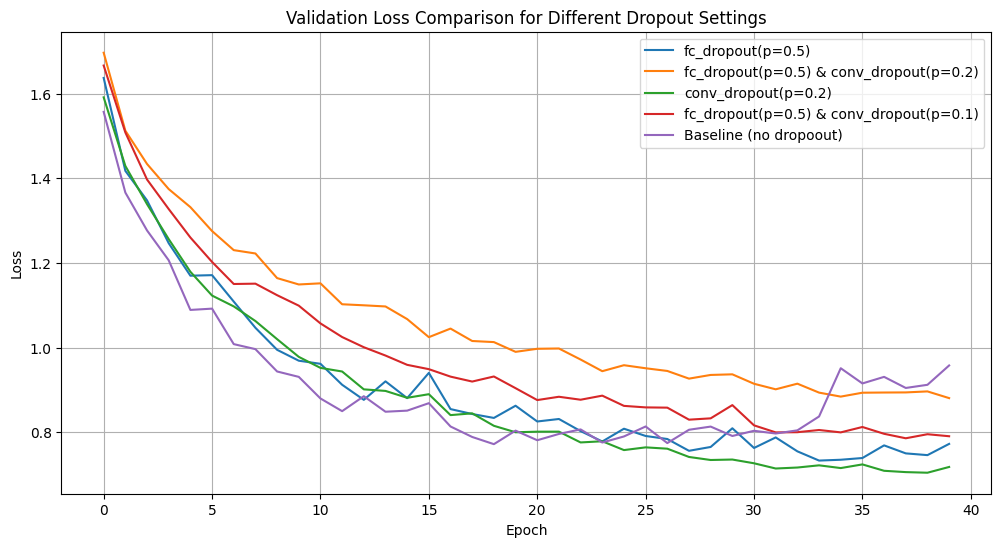

In [10]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline (no dropoout)')

plt.title('Validation Loss Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

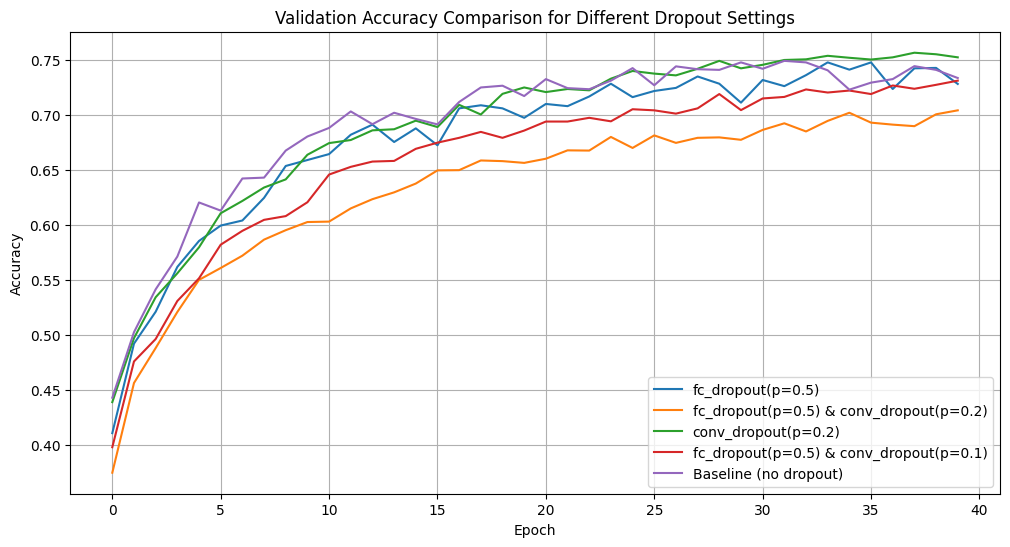

In [11]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline (no dropout)')

plt.title('Validation Accuracy Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (no dropout)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (no dropout),0.307193,0.957867,0.7336
fc_dropout(p=0.5),0.719179,0.772563,0.7282
fc_dropout(p=0.5) & conv_dropout(p=0.2),1.085659,0.880709,0.7042
conv_dropout(p=0.2),0.780744,0.718050,0.7524
fc_dropout(p=0.5) & conv_dropout(p=0.1),0.943259,0.790634,0.7312


### Dropout on 1000 sample train set

Using device:  cuda:0
Trying dropout setting: fc_dropout(p=0.5)
Val loss at epoch 0: 2.2722244773147624
Val acc at epoch 0: 0.13669387755102042
Val loss at epoch 10: 1.938894420784385
Val acc at epoch 10: 0.274265306122449
Val loss at epoch 20: 1.723589738028479
Val acc at epoch 20: 0.3703265306122449
Val loss at epoch 30: 1.7009643804155503
Val acc at epoch 30: 0.3632448979591837
Val loss at epoch 40: 1.6054655367960817
Val acc at epoch 40: 0.41146938775510206
Val loss at epoch 50: 1.5806026006647562
Val acc at epoch 50: 0.42014285714285715
Val loss at epoch 60: 1.5493536018827254
Val acc at epoch 60: 0.43048979591836734
Val loss at epoch 70: 1.5977209351237076
Val acc at epoch 70: 0.4310612244897959
Val loss at epoch 80: 1.5330533747106556
Val acc at epoch 80: 0.45348979591836736
Val loss at epoch 90: 1.556473630837921
Val acc at epoch 90: 0.4516530612244898
Val loss at epoch 100: 1.5524177869135032
Val acc at epoch 100: 0.4638775510204082
Val loss at epoch 110: 1.5539741839036618
Va

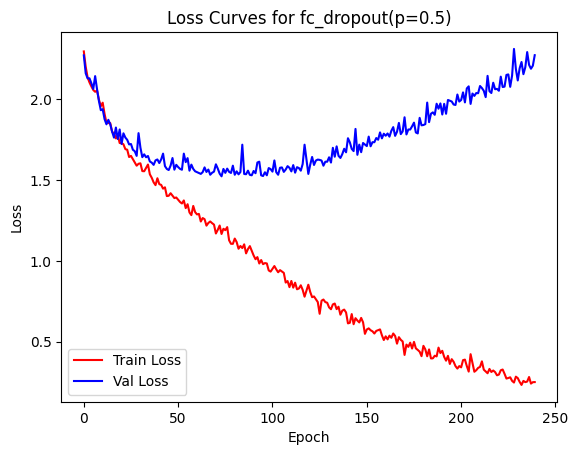

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.2)
Val loss at epoch 0: 2.298098225973294
Val acc at epoch 0: 0.09944897959183674
Val loss at epoch 10: 1.9634961546556757
Val acc at epoch 10: 0.25044897959183676
Val loss at epoch 20: 1.8268135375982788
Val acc at epoch 20: 0.30681632653061225
Val loss at epoch 30: 1.7438311782269191
Val acc at epoch 30: 0.3726938775510204
Val loss at epoch 40: 1.7062544776783288
Val acc at epoch 40: 0.3750204081632653
Val loss at epoch 50: 1.6152156919007512
Val acc at epoch 50: 0.4079795918367347
Val loss at epoch 60: 1.5841822901998426
Val acc at epoch 60: 0.42191836734693877
Val loss at epoch 70: 1.558302623484838
Val acc at epoch 70: 0.42757142857142855
Val loss at epoch 80: 1.539549065009732
Val acc at epoch 80: 0.43495918367346936
Val loss at epoch 90: 1.5155092987472645
Val acc at epoch 90: 0.4356326530612245
Val loss at epoch 100: 1.5110777918414722
Val acc at epoch 100: 0.4443061224489796
Val loss at epoch 110: 1.498668491529111
V

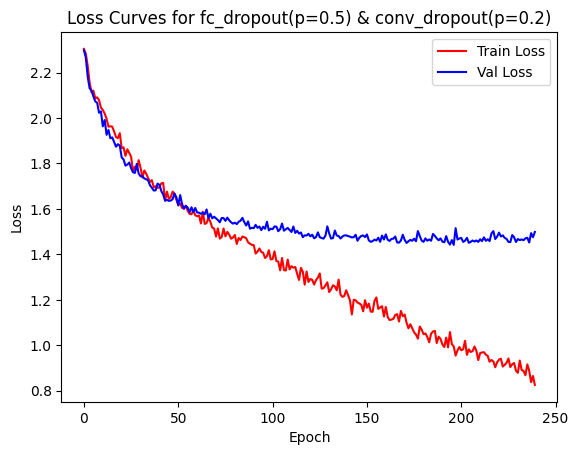

Trying dropout setting: conv_dropout(p=0.2)
Val loss at epoch 0: 2.2816734198801822
Val acc at epoch 0: 0.17342857142857143
Val loss at epoch 10: 1.9180498459320467
Val acc at epoch 10: 0.2885714285714286
Val loss at epoch 20: 1.7727614384407162
Val acc at epoch 20: 0.3436326530612245
Val loss at epoch 30: 1.6923926352832086
Val acc at epoch 30: 0.38173469387755105
Val loss at epoch 40: 1.629431977673548
Val acc at epoch 40: 0.39318367346938776
Val loss at epoch 50: 1.5899131460694047
Val acc at epoch 50: 0.41051020408163263
Val loss at epoch 60: 1.550870817650703
Val acc at epoch 60: 0.4253061224489796
Val loss at epoch 70: 1.5627320140366765
Val acc at epoch 70: 0.4326122448979592
Val loss at epoch 80: 1.5267268743745341
Val acc at epoch 80: 0.44410204081632654
Val loss at epoch 90: 1.5044561781708938
Val acc at epoch 90: 0.46338775510204083
Val loss at epoch 100: 1.5255341452811468
Val acc at epoch 100: 0.4598163265306122
Val loss at epoch 110: 1.5219181622755433
Val acc at epoch 11

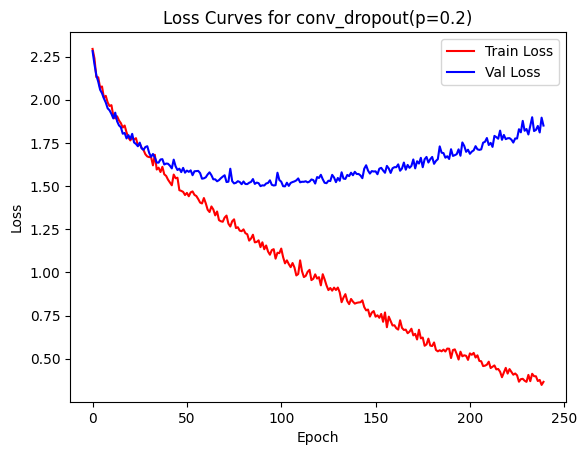

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.1)
Val loss at epoch 0: 2.2869935651983355
Val acc at epoch 0: 0.14187755102040817
Val loss at epoch 10: 1.988323596921353
Val acc at epoch 10: 0.26910204081632655
Val loss at epoch 20: 1.802974265175762
Val acc at epoch 20: 0.3359591836734694
Val loss at epoch 30: 1.7223217441425622
Val acc at epoch 30: 0.3546938775510204
Val loss at epoch 40: 1.6440894816936462
Val acc at epoch 40: 0.3924489795918367
Val loss at epoch 50: 1.625859949047198
Val acc at epoch 50: 0.38810204081632654
Val loss at epoch 60: 1.566601793386295
Val acc at epoch 60: 0.43051020408163265
Val loss at epoch 70: 1.5385501688205232
Val acc at epoch 70: 0.4346122448979592
Val loss at epoch 80: 1.51534864718858
Val acc at epoch 80: 0.4456530612244898
Val loss at epoch 90: 1.5067546934900957
Val acc at epoch 90: 0.4501428571428571
Val loss at epoch 100: 1.4861273551578622
Val acc at epoch 100: 0.45685714285714285
Val loss at epoch 110: 1.503990381644849
Val a

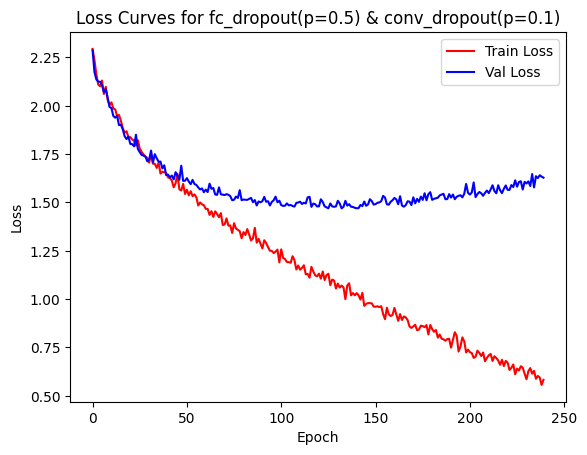

In [14]:
trainset, valset = torch.utils.data.random_split(dataset, [1000, 49000], generator=torch.Generator().manual_seed(42))

configs = [ {'name': 'fc_dropout(p=0.5)','build_model': lambda: build_model_task4_fc_only(10, 0.5)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.2)},
            {'name': 'conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_conv_only(10, p_conv=0.2)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.1)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.1)}
          ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying dropout setting: {config['name']}")

    model_builder = config['build_model']

    model, model_inference = model_builder()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(240):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        if e % 10 == 0:
          print(f"Val loss at epoch {e}: {val_loss}")
          print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [15]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'dropout_results_1k.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to dropout_results_1k.json


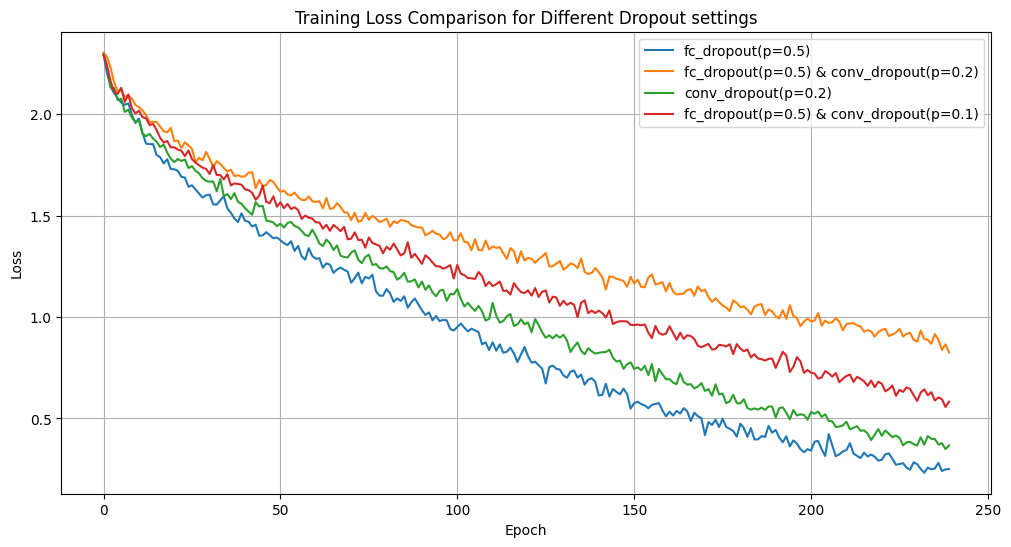

In [20]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

#plt.plot(baseline_train_losses, label='Baseline(no dropout)')

plt.title('Training Loss Comparison for Different Dropout settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

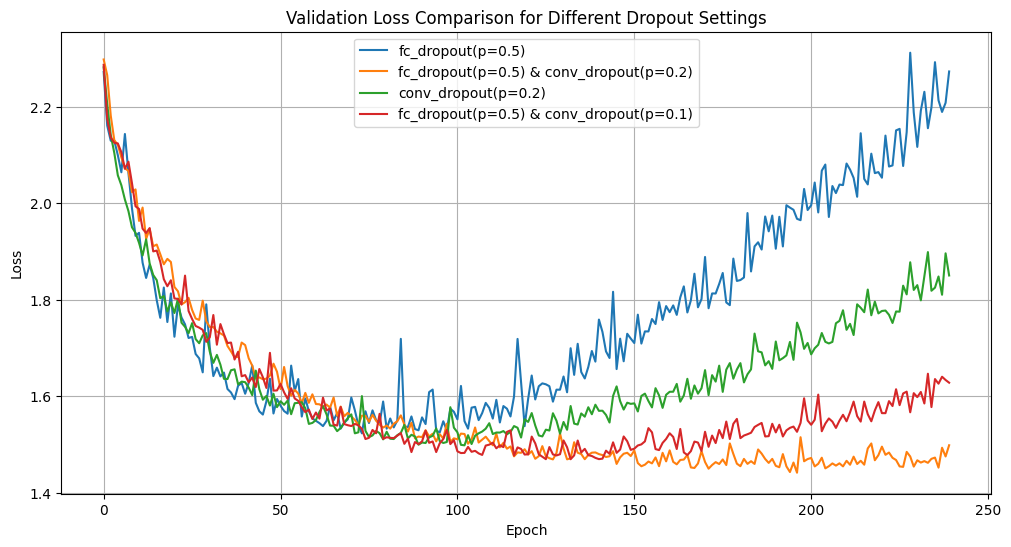

In [21]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

#plt.plot(baseline_val_losses, label='Baseline (no dropoout)')

plt.title('Validation Loss Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

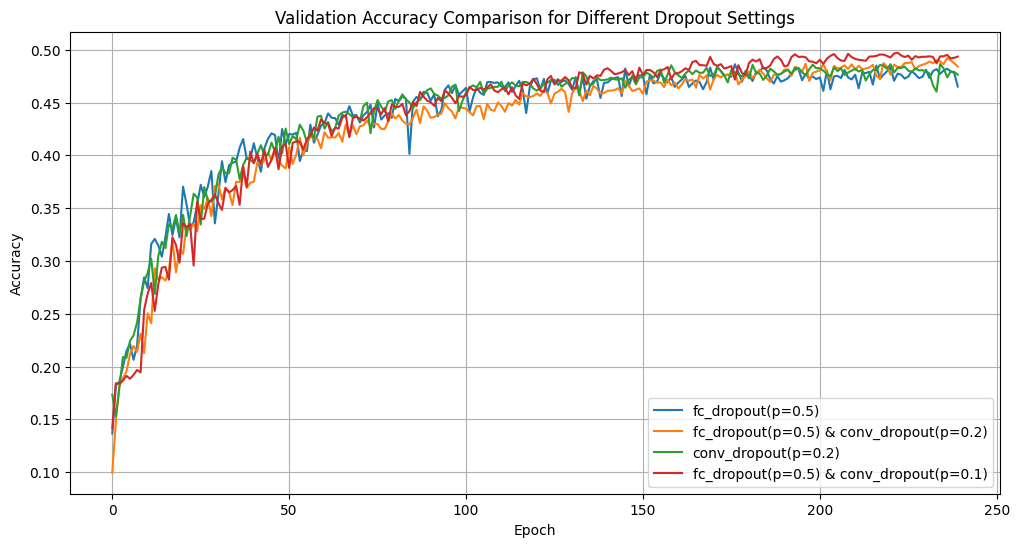

In [22]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

#plt.plot(baseline_val_accs, label='Baseline (no dropout)')

plt.title('Validation Accuracy Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import pandas as pd

summary_data = {}

# Get baseline results
#summary_data['Baseline (no dropout)'] = {
#    'Final Train Loss': baseline_train_losses[-1],
#    'Final Val Loss': baseline_val_losses[-1],
#    'Final Val Accuracy': baseline_val_accs[-1]
#}

for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
fc_dropout(p=0.5),0.249554,2.273217,0.465163
fc_dropout(p=0.5) & conv_dropout(p=0.2),0.825672,1.498740,0.484061
conv_dropout(p=0.2),0.366366,1.850514,0.476327
fc_dropout(p=0.5) & conv_dropout(p=0.1),0.582644,1.628339,0.493531
